In [1]:
# ============================================
# BASELINE MODEL
# CELL 1 — IMPORTS AND PROJECT SETUP
# ============================================

from pathlib import Path
import sys

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Libraries imported successfully")

PROJECT_ROOT = Path(
    r"C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x"
)

print("Project root:", PROJECT_ROOT)
print("Exists:", PROJECT_ROOT.exists())

sys.path.append(str(PROJECT_ROOT))

from src.preprocessing.preprocessing import (
    prepare_features,
    scale_features
)

print("Preprocessing utilities imported successfully")

Libraries imported successfully
Project root: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x
Exists: True
Preprocessing utilities imported successfully


In [2]:
# ============================================
# BASELINE MODEL
# CELL 2 — LOAD FINAL DATASET
# ============================================

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishguard_features_final_11500.csv"
)

df_model = pd.read_csv(DATA_FILE)

print("========== FINAL DATASET ==========")
print("Shape:", df_model.shape)

print("\nColumns:")
print(df_model.columns.tolist())

print("\nLabel distribution:")
print(df_model["Label"].value_counts().sort_index())

print("\nMissing values:")
print(df_model.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_model.duplicated().sum())

print("\n========== VALIDATION RESULT ==========")

if (
    df_model.shape == (11500, 18)
    and df_model["Label"].value_counts().sort_index().to_dict()
        == {0: 6500, 1: 5000}
    and df_model.isnull().sum().sum() == 0
):
    print("PASS: Final 11,500-row dataset loaded correctly.")
else:
    print("WARNING: Dataset validation failed.")

========== FINAL DATASET ==========
Shape: (11500, 18)

Columns:
['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']

Label distribution:
Label
0    6500
1    5000
Name: count, dtype: int64

Missing values:
0

Duplicate rows:
6170

========== VALIDATION RESULT ==========
PASS: Final 11,500-row dataset loaded correctly.


In [3]:
# ============================================
# BASELINE MODEL
# CELL 3 — PREPARE FEATURES AND TARGET
# ============================================

X = prepare_features(df_model)
y = df_model["Label"].copy()

print("========== FEATURE MATRIX ==========")
print("X shape:", X.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\n========== TARGET ==========")
print("y shape:", y.shape)

print("\nLabel distribution:")
print(y.value_counts().sort_index())

print("\n========== VALIDATION RESULT ==========")

if (
    X.shape == (11500, 15)
    and
    list(X.columns) == [
        "Have_IP",
        "Have_At",
        "URL_Length",
        "URL_Depth",
        "Redirection",
        "https_Domain",
        "TinyURL",
        "Prefix/Suffix",
        "DNS_Record",
        "Web_Traffic",
        "Domain_Age",
        "Domain_End",
        "iFrame",
        "Mouse_Over",
        "Web_Forwards"
    ]
    and
    y.shape[0] == 11500
):
    print("PASS: Final 15 model features prepared correctly.")
    print("PASS: Label separated from feature matrix.")
else:
    print("WARNING: Feature preparation validation failed.")

========== FEATURE MATRIX ==========
X shape: (11500, 15)

Feature columns:
['Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Web_Forwards']

========== TARGET ==========
y shape: (11500,)

Label distribution:
Label
0    6500
1    5000
Name: count, dtype: int64

========== VALIDATION RESULT ==========
PASS: Final 15 model features prepared correctly.
PASS: Label separated from feature matrix.


In [4]:
# ============================================
# BASELINE MODEL
# CELL 4 — DOMAIN-AWARE TRAIN/TEST SPLIT
# ============================================

from sklearn.model_selection import GroupShuffleSplit

print("========== DOMAIN-AWARE TRAIN/TEST SPLIT ==========")

groups = df_model["Domain"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("\n========== SHAPES ==========")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\n========== LABEL DISTRIBUTION ==========")
print("Training:")
print(y_train.value_counts().sort_index())

print("\nTesting:")
print(y_test.value_counts().sort_index())

print("\n========== DOMAIN INFORMATION ==========")

train_domains = set(groups_train)
test_domains = set(groups_test)

domain_overlap = train_domains.intersection(test_domains)

print("Training domains:", len(train_domains))
print("Testing domains:", len(test_domains))
print("Domain overlap:", len(domain_overlap))

print("\n========== VALIDATION RESULT ==========")

if (
    X_train.shape == (9111, 15)
    and
    X_test.shape == (2389, 15)
    and
    len(domain_overlap) == 0
):
    print("PASS: Domain-aware split reproduced correctly.")
    print("PASS: No domain overlap between train and test.")
else:
    print("WARNING: Domain-aware split validation failed.")

========== DOMAIN-AWARE TRAIN/TEST SPLIT ==========

========== SHAPES ==========
X_train: (9111, 15)
X_test: (2389, 15)

========== LABEL DISTRIBUTION ==========
Training:
Label
0    5111
1    4000
Name: count, dtype: int64

Testing:
Label
0    1389
1    1000
Name: count, dtype: int64

========== DOMAIN INFORMATION ==========
Training domains: 3953
Testing domains: 989
Domain overlap: 0

========== VALIDATION RESULT ==========
PASS: Domain-aware split reproduced correctly.
PASS: No domain overlap between train and test.


In [5]:
# ============================================
# BASELINE MODEL
# CELL 5 — SCALE FEATURES
# ============================================

X_train_scaled, X_test_scaled, scaler = scale_features(
    X_train,
    X_test
)

print("========== SCALED FEATURES ==========")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("\n========== SCALER ==========")
print("Scaler:", type(scaler).__name__)
print("Number of features:", scaler.n_features_in_)

print("\n========== TRAINING STATISTICS ==========")

print(
    "Mean range:",
    X_train_scaled.mean(axis=0).min(),
    "to",
    X_train_scaled.mean(axis=0).max()
)

print(
    "Std range:",
    X_train_scaled.std(axis=0).min(),
    "to",
    X_train_scaled.std(axis=0).max()
)

print("\n========== VALIDATION RESULT ==========")

if (
    X_train_scaled.shape == (9111, 15)
    and
    X_test_scaled.shape == (2389, 15)
    and
    scaler.n_features_in_ == 15
    and
    np.allclose(X_train_scaled.mean(axis=0), 0, atol=1e-10)
    and
    np.allclose(X_train_scaled.std(axis=0), 1, atol=1e-10)
):
    print("PASS: Features scaled correctly.")
    print("PASS: Scaler fitted only on training data.")
else:
    print("WARNING: Scaling validation failed.")

========== SCALED FEATURES ==========
X_train_scaled shape: (9111, 15)
X_test_scaled shape: (2389, 15)

========== SCALER ==========
Scaler: StandardScaler
Number of features: 15

========== TRAINING STATISTICS ==========
Mean range: -1.4544640568462155e-16 to 7.486785493685612e-17
Std range: 0.9999999999999999 to 1.0000000000000002

========== VALIDATION RESULT ==========
PASS: Features scaled correctly.
PASS: Scaler fitted only on training data.


In [6]:
# ============================================
# BASELINE MODEL
# CELL 6 — BASELINE MODEL DEFINITIONS
# ============================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM RBF": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

print("========== BASELINE MODELS ==========")

for name, model in models.items():
    print(f"{name}: {type(model).__name__}")

print("\nNumber of baseline models:", len(models))

print("\n========== VALIDATION RESULT ==========")

if len(models) == 6:
    print("PASS: All 6 baseline models defined.")
else:
    print("WARNING: Baseline model count mismatch.")

========== BASELINE MODELS ==========
Logistic Regression: LogisticRegression
KNN: KNeighborsClassifier
SVM RBF: SVC
Decision Tree: DecisionTreeClassifier
Random Forest: RandomForestClassifier
XGBoost: XGBClassifier

Number of baseline models: 6

========== VALIDATION RESULT ==========
PASS: All 6 baseline models defined.


In [7]:
# ============================================
# BASELINE MODEL
# CELL 7 — TRAIN AND EVALUATE BASELINE MODELS
# ============================================

print("========== BASELINE MODEL TRAINING ==========")

results = []
confusion_matrices = {}

scaled_models = {
    "Logistic Regression",
    "KNN",
    "SVM RBF"
}

for name, model in models.items():

    print(f"\nTraining: {name}")

    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        X_eval = X_test_scaled
    else:
        model.fit(X_train, y_train)
        X_eval = X_test

    y_pred = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        y_score = model.decision_function(X_eval)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, y_score
        )
    }

    results.append(metrics)

    confusion_matrices[name] = confusion_matrix(
        y_test,
        y_pred
    )

baseline_results = pd.DataFrame(results)

baseline_results = baseline_results.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

print("\n========== BASELINE RESULTS ==========")

print(
    baseline_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\n========== CONFUSION MATRICES ==========")

for name, cm in confusion_matrices.items():
    print(f"\n{name}")
    print(cm)

print("\n========== VALIDATION RESULT ==========")

if (
    len(baseline_results) == 6
    and
    set(baseline_results["Model"]) == set(models.keys())
):
    print("PASS: All 6 baseline models trained and evaluated.")
else:
    print("WARNING: Baseline evaluation mismatch.")

========== BASELINE MODEL TRAINING ==========

Training: Logistic Regression

Training: KNN

Training: SVM RBF


c:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Training: Decision Tree

Training: Random Forest

Training: XGBoost

========== BASELINE RESULTS ==========
              Model  Accuracy  Precision  Recall     F1  ROC-AUC
      Decision Tree    0.9008     0.8921  0.8680 0.8799   0.9586
      Random Forest    0.8853     0.8616  0.8650 0.8633   0.9568
Logistic Regression    0.8757     0.8240  0.8940 0.8576   0.9105
                KNN    0.8397     0.7454  0.9370 0.8303   0.8795
            XGBoost    0.8472     0.7900  0.8650 0.8258   0.9560
            SVM RBF    0.8062     0.8604  0.6410 0.7347   0.9220

========== CONFUSION MATRICES ==========

Logistic Regression
[[1198  191]
 [ 106  894]]

KNN
[[1069  320]
 [  63  937]]

SVM RBF
[[1285  104]
 [ 359  641]]

Decision Tree
[[1284  105]
 [ 132  868]]

Random Forest
[[1250  139]
 [ 135  865]]

XGBoost
[[1159  230]
 [ 135  865]]

========== VALIDATION RESULT ==========
PASS: All 6 baseline models trained and evaluated.


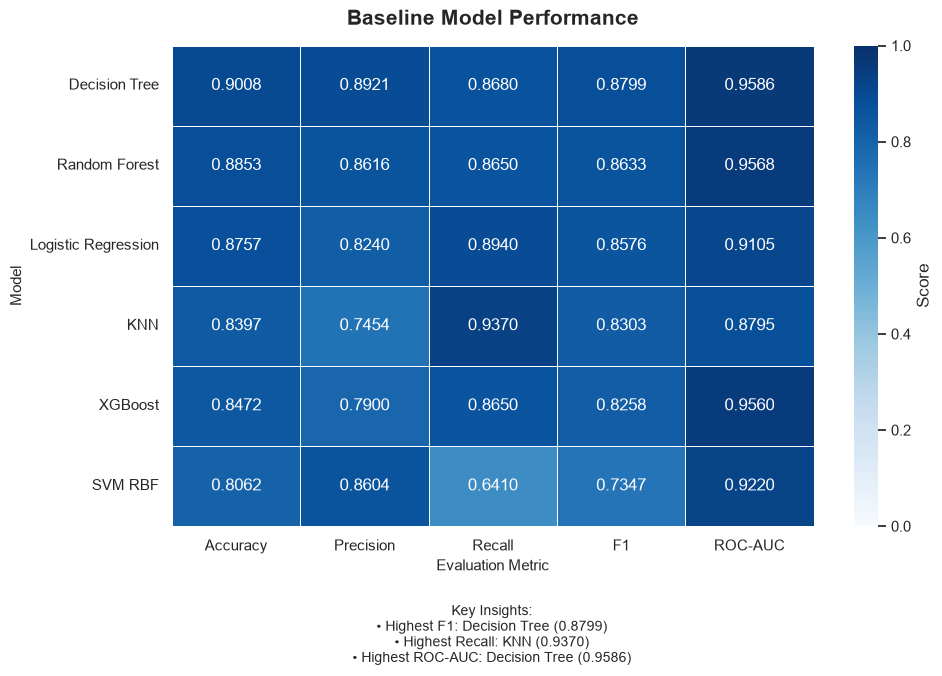

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\baseline_model_performance_heatmap.png


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# Figure output directory
# -----------------------------
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Research-paper style
# -----------------------------
sns.set_theme(
    style="white",
    context="notebook"
)

# -----------------------------
# Prepare heatmap data
# -----------------------------
heatmap_df = baseline_results.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
]

# -----------------------------
# Calculate key insights
# -----------------------------
best_f1_model = baseline_results.loc[
    baseline_results["F1"].idxmax(), "Model"
]

best_f1 = baseline_results["F1"].max()

best_recall_model = baseline_results.loc[
    baseline_results["Recall"].idxmax(), "Model"
]

best_recall = baseline_results["Recall"].max()

best_auc_model = baseline_results.loc[
    baseline_results["ROC-AUC"].idxmax(), "Model"
]

best_auc = baseline_results["ROC-AUC"].max()

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".4f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Score"},
    ax=ax
)

ax.set_title(
    "Baseline Model Performance",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Evaluation Metric", fontsize=11)
ax.set_ylabel("Model", fontsize=11)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

# -----------------------------
# Key Insight
# -----------------------------
insight_text = (
    f"Key Insights:\n"
    f"• Highest F1: {best_f1_model} ({best_f1:.4f})\n"
    f"• Highest Recall: {best_recall_model} ({best_recall:.4f})\n"
    f"• Highest ROC-AUC: {best_auc_model} ({best_auc:.4f})"
)

fig.text(
    0.5,
    -0.02,
    insight_text,
    ha="center",
    va="top",
    fontsize=10
)

plt.tight_layout()

# -----------------------------
# Save high-resolution figure
# -----------------------------
output_path = FIGURE_DIR / "baseline_model_performance_heatmap.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(output_path)

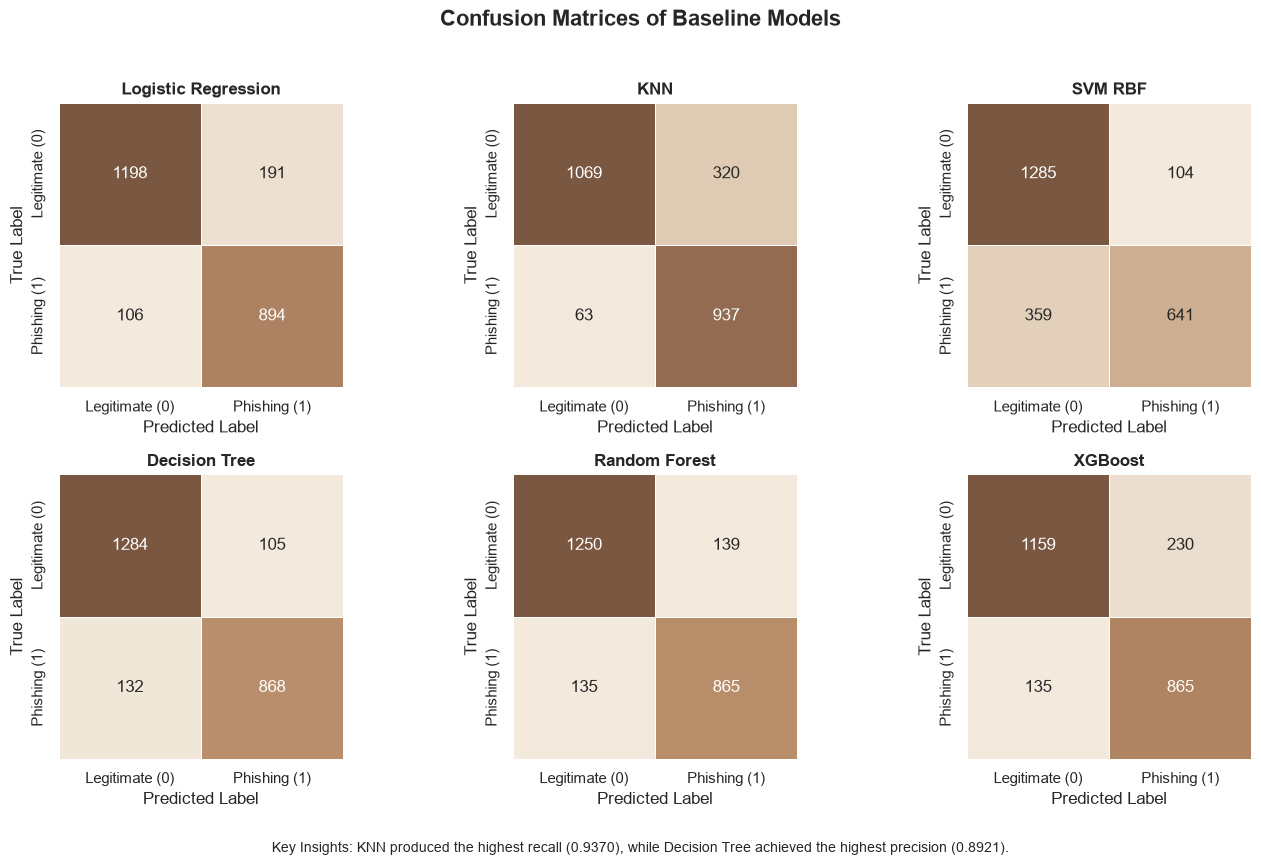

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\baseline_confusion_matrices.png


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# Create 2 x 3 subplot layout
# -----------------------------
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8)
)

axes = axes.flatten()

# -----------------------------
# Muted warm professional theme
# -----------------------------
warm_cmap = LinearSegmentedColormap.from_list(
    "warm_professional",
    [
        "#F3E9DC",
        "#D9C2A7",
        "#B78B68",
        "#7A5741"
    ]
)

# -----------------------------
# Plot confusion matrices
# -----------------------------
for ax, (model_name, cm) in zip(
    axes,
    confusion_matrices.items()
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=warm_cmap,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        square=True,
        ax=ax
    )

    ax.set_title(
        model_name,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    ax.set_xticklabels(
        ["Legitimate (0)", "Phishing (1)"]
    )

    ax.set_yticklabels(
        ["Legitimate (0)", "Phishing (1)"],
        rotation=90
    )

# -----------------------------
# Overall title
# -----------------------------
fig.suptitle(
    "Confusion Matrices of Baseline Models",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

# -----------------------------
# Key insight
# -----------------------------
best_recall_model = baseline_results.loc[
    baseline_results["Recall"].idxmax(),
    "Model"
]

best_precision_model = baseline_results.loc[
    baseline_results["Precision"].idxmax(),
    "Model"
]

insight_text = (
    f"Key Insights: {best_recall_model} produced the highest recall "
    f"({baseline_results['Recall'].max():.4f}), while "
    f"{best_precision_model} achieved the highest precision "
    f"({baseline_results['Precision'].max():.4f})."
)

fig.text(
    0.5,
    -0.02,
    insight_text,
    ha="center",
    va="top",
    fontsize=10
)

plt.tight_layout()

# -----------------------------
# Save high-resolution figure
# -----------------------------
output_path = (
    FIGURE_DIR /
    "baseline_confusion_matrices.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(output_path)

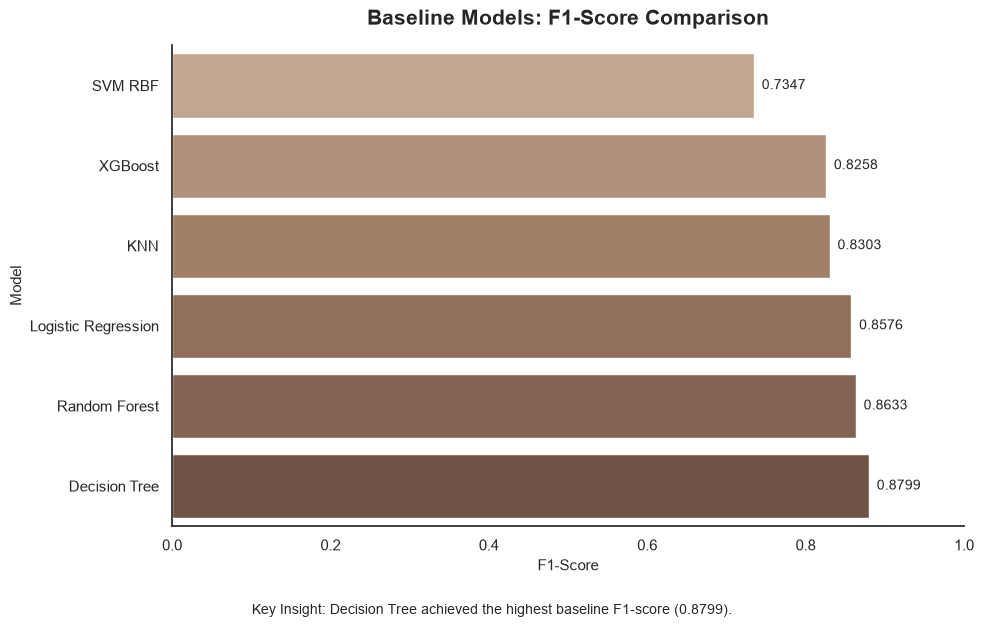

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\baseline_f1_comparison.png


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Sort by F1-score
# -----------------------------
f1_df = baseline_results.sort_values(
    "F1",
    ascending=True
).copy()

# -----------------------------
# Warm, muted academic palette
# -----------------------------
warm_palette = [
    "#C9A58A",
    "#B98F72",
    "#AA7D60",
    "#9A6D52",
    "#8B624A",
    "#76513D"
]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=f1_df,
    x="F1",
    y="Model",
    hue="Model",
    palette=warm_palette,
    legend=False,
    ax=ax
)

ax.set_title(
    "Baseline Models: F1-Score Comparison",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("F1-Score", fontsize=11)
ax.set_ylabel("Model", fontsize=11)

ax.set_xlim(0, 1)

# -----------------------------
# Exact values
# -----------------------------
for i, value in enumerate(f1_df["F1"]):
    ax.text(
        value + 0.01,
        i,
        f"{value:.4f}",
        va="center",
        fontsize=10
    )

# -----------------------------
# Key insight
# -----------------------------
top_model = f1_df.iloc[-1]["Model"]
top_f1 = f1_df.iloc[-1]["F1"]

fig.text(
    0.5,
    -0.02,
    f"Key Insight: {top_model} achieved the highest baseline F1-score ({top_f1:.4f}).",
    ha="center",
    va="top",
    fontsize=10
)

sns.despine()

plt.tight_layout()

# -----------------------------
# Save high-resolution figure
# -----------------------------
output_path = FIGURE_DIR / "baseline_f1_comparison.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(output_path)

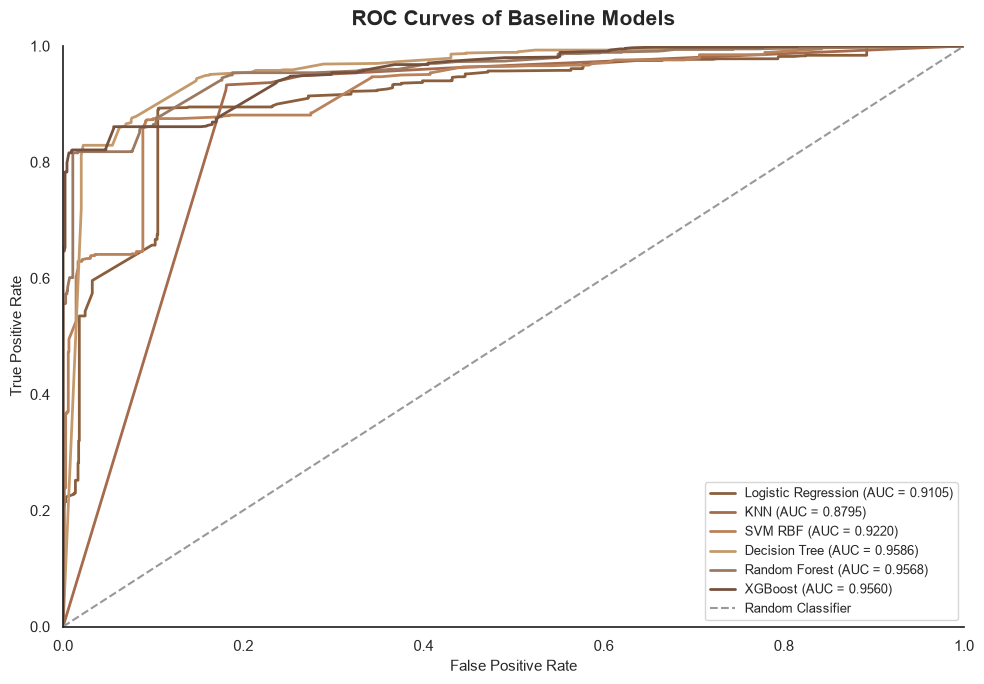

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\baseline_roc_curves.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 7))

warm_colors = [
    "#8B5E3C",
    "#A66A4C",
    "#B9825A",
    "#C49A6C",
    "#9C7A62",
    "#76513D"
]

scaled_models = {
    "Logistic Regression",
    "KNN",
    "SVM RBF"
}

for (model_name, model), color in zip(models.items(), warm_colors):

    if model_name in scaled_models:
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.4f})",
        color=color
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color="#999999",
    label="Random Classifier"
)

ax.set_title(
    "ROC Curves of Baseline Models",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=9
)

sns.despine()
plt.tight_layout()

output_path = FIGURE_DIR / "baseline_roc_curves.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved successfully:")
print(output_path)

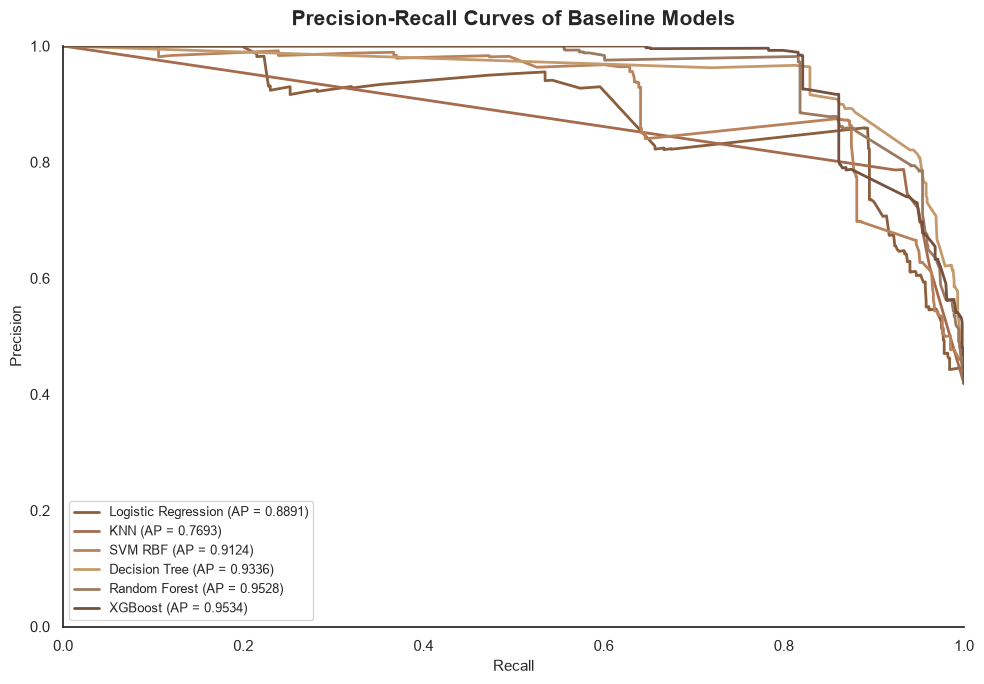

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\baseline_precision_recall_curves.png


In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 7))

warm_colors = [
    "#8B5E3C",
    "#A66A4C",
    "#B9825A",
    "#C49A6C",
    "#9C7A62",
    "#76513D"
]

for (model_name, model), color in zip(models.items(), warm_colors):

    if model_name in scaled_models:
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    avg_precision = average_precision_score(y_test, y_score)

    ax.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AP = {avg_precision:.4f})",
        color=color
    )

ax.set_title(
    "Precision-Recall Curves of Baseline Models",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(
    loc="lower left",
    frameon=True,
    fontsize=9
)

sns.despine()
plt.tight_layout()

output_path = FIGURE_DIR / "baseline_precision_recall_curves.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved successfully:")
print(output_path)

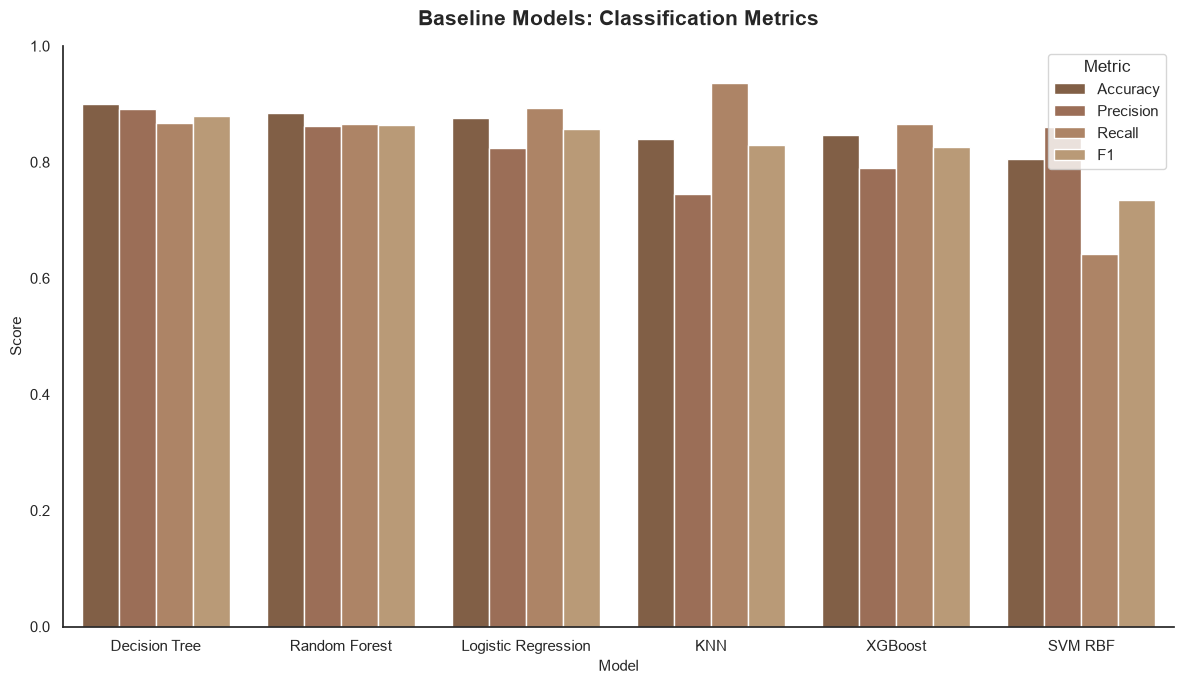

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\baseline_metric_comparison.png


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics_df = baseline_results[
    ["Model", "Accuracy", "Precision", "Recall", "F1"]
].copy()

metrics_long = metrics_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

fig, ax = plt.subplots(figsize=(12, 7))

warm_palette = [
    "#8B5E3C",
    "#A66A4C",
    "#B9825A",
    "#C49A6C"
]

sns.barplot(
    data=metrics_long,
    x="Model",
    y="Score",
    hue="Metric",
    palette=warm_palette,
    ax=ax
)

ax.set_title(
    "Baseline Models: Classification Metrics",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Model", fontsize=11)
ax.set_ylabel("Score", fontsize=11)

ax.set_ylim(0, 1)

ax.legend(
    title="Metric",
    frameon=True
)

sns.despine()
plt.tight_layout()

output_path = FIGURE_DIR / "baseline_metric_comparison.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved successfully:")
print(output_path)

In [15]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

param_distributions = {
    "n_estimators": [100, 150, 200, 250],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.02, 0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

group_kfold = GroupKFold(n_splits=5)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=group_kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

xgb_random_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

print("\nTuning completed successfully.")
print("\nBest Parameters:")
print(xgb_random_search.best_params_)

print("\nBest GroupKFold CV F1-score:")
print(f"{xgb_random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Tuning completed successfully.

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.02, 'colsample_bytree': 0.9}

Best GroupKFold CV F1-score:
0.8402


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

tuned_xgb = xgb_random_search.best_estimator_

y_pred_tuned = tuned_xgb.predict(X_test)
y_prob_tuned = tuned_xgb.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_roc_auc = roc_auc_score(y_test, y_prob_tuned)
tuned_cm = confusion_matrix(y_test, y_pred_tuned)

print("Tuned XGBoost Test Results")
print("-" * 40)
print(f"Accuracy :  {tuned_accuracy:.4f}")
print(f"Precision:  {tuned_precision:.4f}")
print(f"Recall:     {tuned_recall:.4f}")
print(f"F1-Score:   {tuned_f1:.4f}")
print(f"ROC-AUC:    {tuned_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(tuned_cm)

Tuned XGBoost Test Results
----------------------------------------
Accuracy :  0.9108
Precision:  0.9263
Recall:     0.8550
F1-Score:   0.8892
ROC-AUC:    0.9634

Confusion Matrix:
[[1321   68]
 [ 145  855]]


In [17]:
xgb_comparison = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        baseline_results.loc[
            baseline_results["Model"] == "XGBoost", "Accuracy"
        ].iloc[0],
        tuned_accuracy
    ],
    "Precision": [
        baseline_results.loc[
            baseline_results["Model"] == "XGBoost", "Precision"
        ].iloc[0],
        tuned_precision
    ],
    "Recall": [
        baseline_results.loc[
            baseline_results["Model"] == "XGBoost", "Recall"
        ].iloc[0],
        tuned_recall
    ],
    "F1": [
        baseline_results.loc[
            baseline_results["Model"] == "XGBoost", "F1"
        ].iloc[0],
        tuned_f1
    ],
    "ROC-AUC": [
        baseline_results.loc[
            baseline_results["Model"] == "XGBoost", "ROC-AUC"
        ].iloc[0],
        tuned_roc_auc
    ]
})

display(
    xgb_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline XGBoost,0.8472,0.7900,0.8650,0.8258,0.9560
1,Tuned XGBoost,0.9108,0.9263,0.8550,0.8892,0.9634


C:\Users\nk134\AppData\Local\Temp\ipykernel_5272\2781019081.py:20: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(


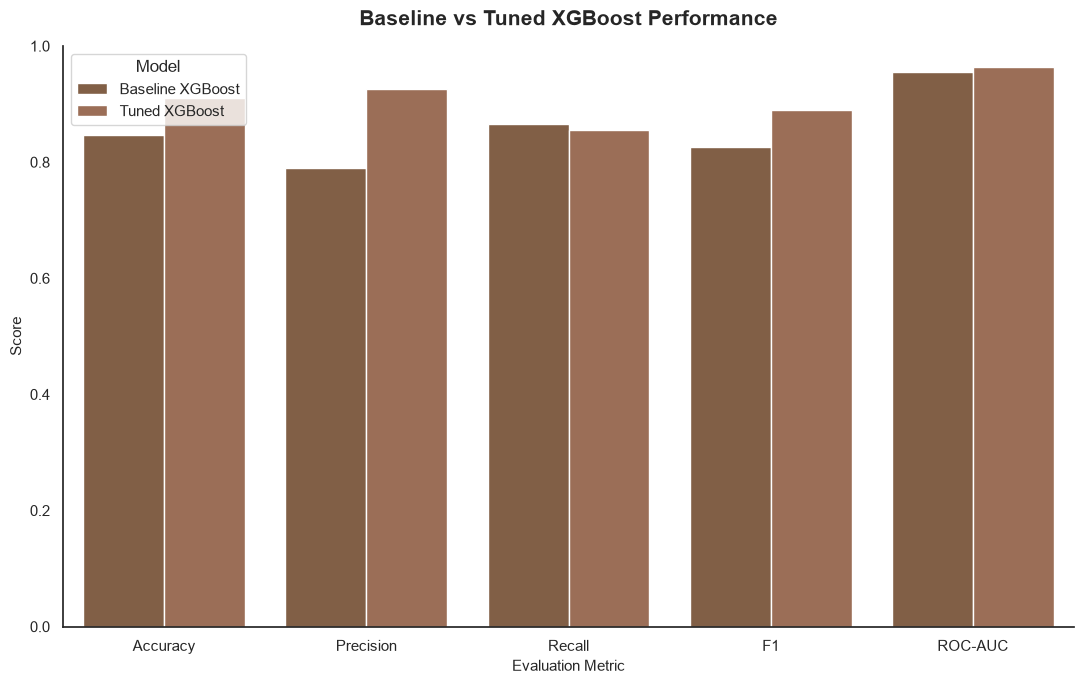

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\baseline_vs_tuned_xgboost.png


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

comparison_long = xgb_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

warm_palette = [
    "#8B5E3C",
    "#A66A4C",
    "#B9825A",
    "#C49A6C",
    "#9C7A62"
]

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette=warm_palette,
    ax=ax
)

ax.set_title(
    "Baseline vs Tuned XGBoost Performance",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Evaluation Metric", fontsize=11)
ax.set_ylabel("Score", fontsize=11)

ax.set_ylim(0, 1)

ax.legend(
    title="Model",
    frameon=True
)

sns.despine()
plt.tight_layout()

output_path = FIGURE_DIR / "baseline_vs_tuned_xgboost.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(output_path)

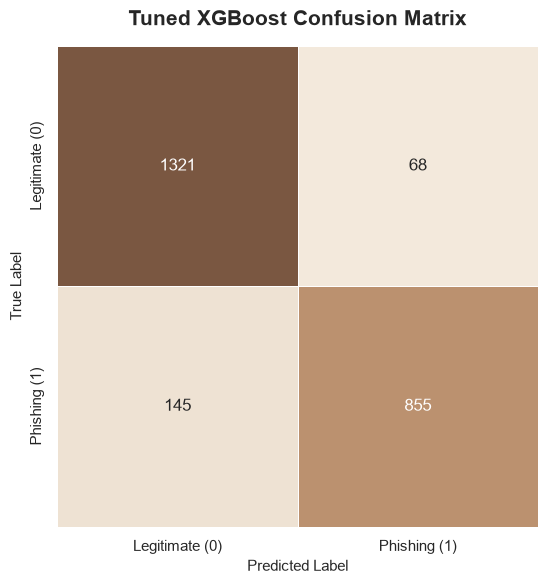

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\tuned_xgboost_confusion_matrix.png


In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

tuned_cm = confusion_matrix(y_test, y_pred_tuned)

warm_cmap = LinearSegmentedColormap.from_list(
    "warm_professional",
    ["#F3E9DC", "#D9C2A7", "#B78B68", "#7A5741"]
)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap=warm_cmap,
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax
)

ax.set_title(
    "Tuned XGBoost Confusion Matrix",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

ax.set_xticklabels(
    ["Legitimate (0)", "Phishing (1)"]
)

ax.set_yticklabels(
    ["Legitimate (0)", "Phishing (1)"],
    rotation=90
)

plt.tight_layout()

output_path = FIGURE_DIR / "tuned_xgboost_confusion_matrix.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(output_path)

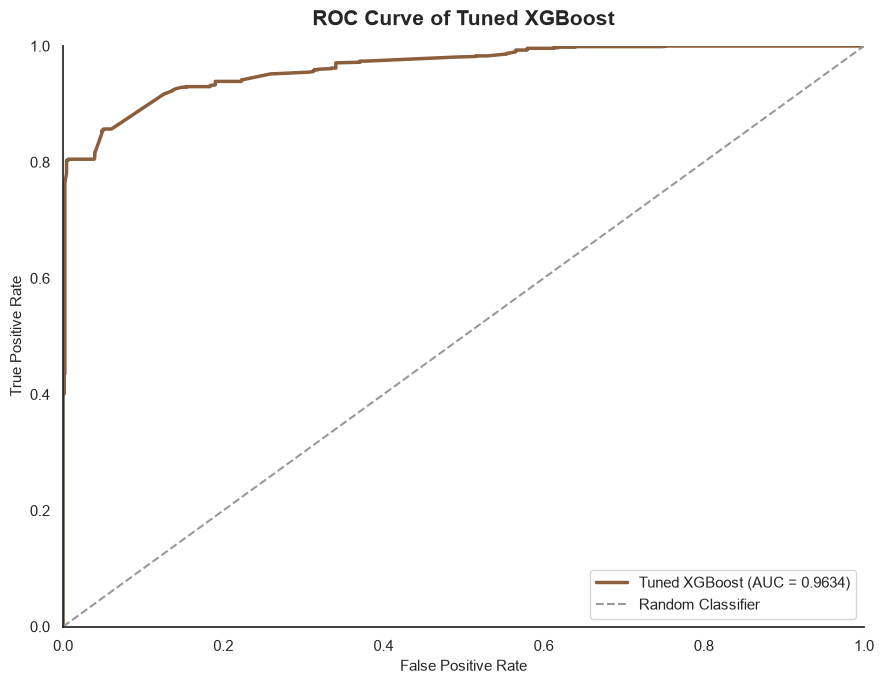

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\tuned_xgboost_roc_curve.png


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_tuned)
roc_auc = roc_auc_score(y_test, y_prob_tuned)

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(
    fpr,
    tpr,
    linewidth=2.5,
    color="#8B5E3C",
    label=f"Tuned XGBoost (AUC = {roc_auc:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color="#999999",
    label="Random Classifier"
)

ax.set_title(
    "ROC Curve of Tuned XGBoost",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(
    loc="lower right",
    frameon=True
)

sns.despine()
plt.tight_layout()

output_path = FIGURE_DIR / "tuned_xgboost_roc_curve.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(output_path)

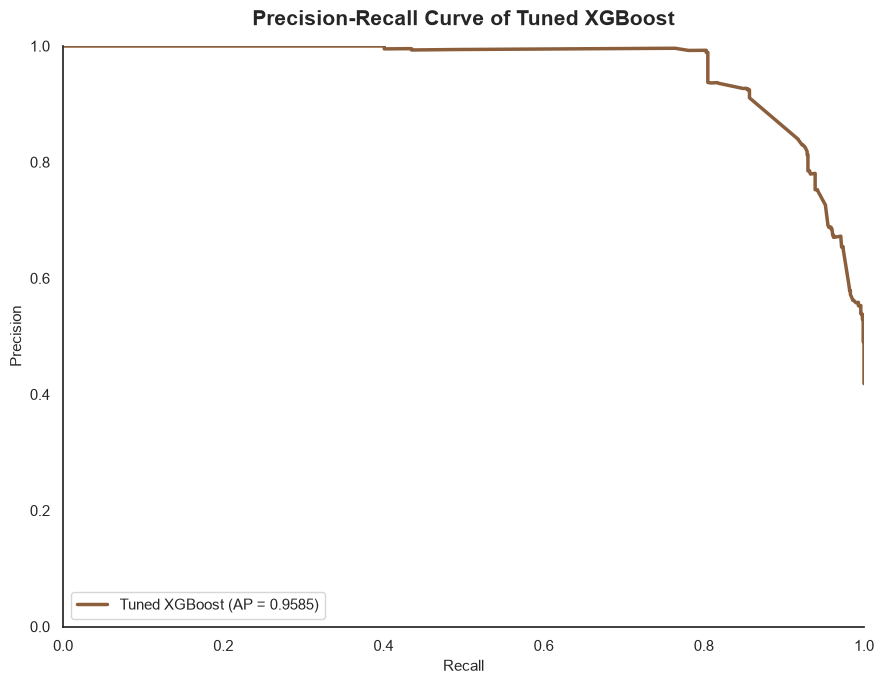

Average Precision: 0.9585
Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\tuned_xgboost_precision_recall_curve.png


In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob_tuned
)

avg_precision = average_precision_score(
    y_test,
    y_prob_tuned
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(
    recall,
    precision,
    linewidth=2.5,
    color="#8B5E3C",
    label=f"Tuned XGBoost (AP = {avg_precision:.4f})"
)

ax.set_title(
    "Precision-Recall Curve of Tuned XGBoost",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(
    loc="lower left",
    frameon=True
)

sns.despine()
plt.tight_layout()

output_path = FIGURE_DIR / "tuned_xgboost_precision_recall_curve.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Average Precision:", f"{avg_precision:.4f}")
print("Figure saved successfully:")
print(output_path)

Threshold Selection Using GroupKFold
---------------------------------------------
Selected Threshold: 0.48
Cross-Validated F1:  0.8399


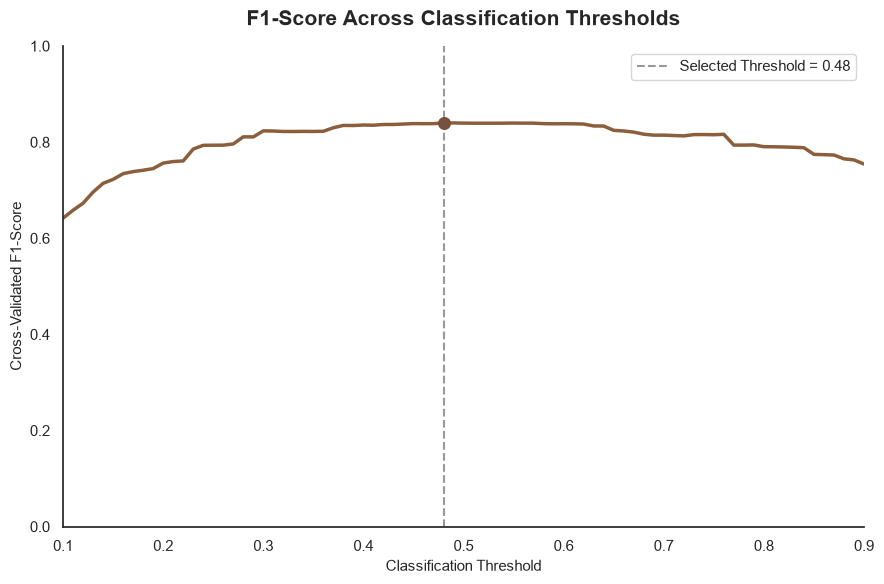


Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\tuned_xgboost_threshold_analysis.png


In [22]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

group_kfold = GroupKFold(n_splits=5)

cv_probabilities = cross_val_predict(
    tuned_xgb,
    X_train,
    y_train,
    groups=groups_train,
    cv=group_kfold,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

cv_f1_scores = []

for threshold in thresholds:
    cv_predictions = (cv_probabilities >= threshold).astype(int)
    cv_f1_scores.append(
        f1_score(y_train, cv_predictions)
    )

best_threshold_idx = np.argmax(cv_f1_scores)
selected_threshold = thresholds[best_threshold_idx]
selected_cv_f1 = cv_f1_scores[best_threshold_idx]

print("Threshold Selection Using GroupKFold")
print("-" * 45)
print(f"Selected Threshold: {selected_threshold:.2f}")
print(f"Cross-Validated F1:  {selected_cv_f1:.4f}")

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    thresholds,
    cv_f1_scores,
    linewidth=2.5,
    color="#8B5E3C"
)

ax.axvline(
    selected_threshold,
    linestyle="--",
    linewidth=1.5,
    color="#999999",
    label=f"Selected Threshold = {selected_threshold:.2f}"
)

ax.scatter(
    selected_threshold,
    selected_cv_f1,
    s=70,
    color="#76513D",
    zorder=5
)

ax.set_title(
    "F1-Score Across Classification Thresholds",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Classification Threshold", fontsize=11)
ax.set_ylabel("Cross-Validated F1-Score", fontsize=11)

ax.set_xlim(0.10, 0.90)
ax.set_ylim(0, 1)

ax.legend(frameon=True)

sns.despine()
plt.tight_layout()

output_path = FIGURE_DIR / "tuned_xgboost_threshold_analysis.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved successfully:")
print(output_path)

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Apply the threshold selected from training CV
y_pred_threshold = (
    y_prob_tuned >= selected_threshold
).astype(int)

threshold_accuracy = accuracy_score(
    y_test,
    y_pred_threshold
)

threshold_precision = precision_score(
    y_test,
    y_pred_threshold
)

threshold_recall = recall_score(
    y_test,
    y_pred_threshold
)

threshold_f1 = f1_score(
    y_test,
    y_pred_threshold
)

threshold_roc_auc = roc_auc_score(
    y_test,
    y_prob_tuned
)

threshold_cm = confusion_matrix(
    y_test,
    y_pred_threshold
)

print("Tuned XGBoost — Threshold-Based Test Results")
print("-" * 55)
print(f"Threshold :  {selected_threshold:.2f}")
print(f"Accuracy  :  {threshold_accuracy:.4f}")
print(f"Precision :  {threshold_precision:.4f}")
print(f"Recall    :  {threshold_recall:.4f}")
print(f"F1-Score  :  {threshold_f1:.4f}")
print(f"ROC-AUC   :  {threshold_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(threshold_cm)

Tuned XGBoost — Threshold-Based Test Results
-------------------------------------------------------
Threshold :  0.48
Accuracy  :  0.9108
Precision :  0.9263
Recall    :  0.8550
F1-Score  :  0.8892
ROC-AUC   :  0.9634

Confusion Matrix:
[[1321   68]
 [ 145  855]]


In [25]:
import joblib

FINAL_FEATURES = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Web_Forwards",
]

MODEL_PATH = PROJECT_ROOT / "models" / "tuned_xgboost_final.joblib"
FEATURES_PATH = PROJECT_ROOT / "models" / "final_features.joblib"
THRESHOLD_PATH = PROJECT_ROOT / "models" / "classification_threshold.joblib"

joblib.dump(tuned_xgb, MODEL_PATH)
joblib.dump(FINAL_FEATURES, FEATURES_PATH)
joblib.dump(selected_threshold, THRESHOLD_PATH)

print("Final model artifacts saved successfully.")
print()
print("Model:", MODEL_PATH)
print("Features:", FEATURES_PATH)
print("Threshold:", THRESHOLD_PATH)

Final model artifacts saved successfully.

Model: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\models\tuned_xgboost_final.joblib
Features: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\models\final_features.joblib
Threshold: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\models\classification_threshold.joblib


In [27]:
from src.features.url_features import featureExtraction, feature_names

print("Feature extraction imported successfully.")
print("Number of features:", len(feature_names))

Tranco domains loaded: 4384729
Feature extraction imported successfully.
Number of features: 18


In [28]:
import joblib
import pandas as pd

# Load saved model and saved feature list
loaded_model = joblib.load(
    PROJECT_ROOT / "models" / "tuned_xgboost_final.joblib"
)

loaded_features = joblib.load(
    PROJECT_ROOT / "models" / "final_features.joblib"
)

loaded_threshold = joblib.load(
    PROJECT_ROOT / "models" / "classification_threshold.joblib"
)

# Famous URL
test_url = "https://www.google.com"

# Extract features
test_features = featureExtraction(test_url, 0)

# Convert extracted features into DataFrame
test_df = pd.DataFrame(
    [test_features],
    columns=feature_names
)

# Select exactly the 15 features used by the final model
X_famous = test_df[loaded_features]

# Model prediction
phishing_probability = loaded_model.predict_proba(X_famous)[0, 1]

prediction = int(
    phishing_probability >= loaded_threshold
)

print("Test URL:", test_url)
print()
print("Phishing Probability:", f"{phishing_probability:.4f}")
print("Classification Threshold:", f"{loaded_threshold:.2f}")
print()

if prediction == 1:
    print("Prediction: PHISHING")
else:
    print("Prediction: LEGITIMATE")

Test URL: https://www.google.com

Phishing Probability: 0.3602
Classification Threshold: 0.48

Prediction: LEGITIMATE


In [29]:
legitimate_urls = [
    "https://www.google.com",
    "https://www.microsoft.com",
    "https://www.apple.com",
    "https://www.github.com",
    "https://www.youtube.com"
]

for test_url in legitimate_urls:
    test_features = featureExtraction(test_url, 0)
    test_df = pd.DataFrame([test_features], columns=feature_names)

    X_test_url = test_df[loaded_features]

    phishing_probability = loaded_model.predict_proba(X_test_url)[0, 1]
    prediction = int(phishing_probability >= loaded_threshold)

    print(f"URL: {test_url}")
    print(f"Phishing Probability: {phishing_probability:.4f}")
    print(f"Prediction: {'PHISHING' if prediction == 1 else 'LEGITIMATE'}")
    print("-" * 60)

URL: https://www.google.com
Phishing Probability: 0.3602
Prediction: LEGITIMATE
------------------------------------------------------------
URL: https://www.microsoft.com
Phishing Probability: 0.1848
Prediction: LEGITIMATE
------------------------------------------------------------
URL: https://www.apple.com
Phishing Probability: 0.1153
Prediction: LEGITIMATE
------------------------------------------------------------
URL: https://www.github.com
Phishing Probability: 0.3602
Prediction: LEGITIMATE
------------------------------------------------------------
URL: https://www.youtube.com
Phishing Probability: 0.0635
Prediction: LEGITIMATE
------------------------------------------------------------


In [30]:
phishing_urls = [
    "http://paypal-login-security.com",
    "http://google-verification-account.com",
    "http://microsoft-security-check.com",
    "http://appleid-verification-login.com",
    "http://facebook-account-verify.com"
]

for test_url in phishing_urls:
    test_features = featureExtraction(test_url, 1)
    test_df = pd.DataFrame([test_features], columns=feature_names)

    X_test_url = test_df[loaded_features]

    phishing_probability = loaded_model.predict_proba(X_test_url)[0, 1]
    prediction = int(phishing_probability >= loaded_threshold)

    print(f"URL: {test_url}")
    print(f"Phishing Probability: {phishing_probability:.4f}")
    print(f"Prediction: {'PHISHING' if prediction == 1 else 'LEGITIMATE'}")
    print("-" * 60)

URL: http://paypal-login-security.com
Phishing Probability: 0.9826
Prediction: PHISHING
------------------------------------------------------------
URL: http://google-verification-account.com
Phishing Probability: 0.9794
Prediction: PHISHING
------------------------------------------------------------
URL: http://microsoft-security-check.com
Phishing Probability: 0.9826
Prediction: PHISHING
------------------------------------------------------------
URL: http://appleid-verification-login.com
Phishing Probability: 0.9826
Prediction: PHISHING
------------------------------------------------------------
URL: http://facebook-account-verify.com
Phishing Probability: 0.9826
Prediction: PHISHING
------------------------------------------------------------


In [31]:
validation_results = []

# Legitimate URLs
for test_url in legitimate_urls:
    test_features = featureExtraction(test_url, 0)
    test_df = pd.DataFrame([test_features], columns=feature_names)
    X_test_url = test_df[loaded_features]

    phishing_probability = loaded_model.predict_proba(X_test_url)[0, 1]
    prediction = int(phishing_probability >= loaded_threshold)

    validation_results.append({
        "URL": test_url,
        "Actual": "LEGITIMATE",
        "Phishing_Probability": phishing_probability,
        "Prediction": "PHISHING" if prediction == 1 else "LEGITIMATE"
    })

# Phishing URLs
for test_url in phishing_urls:
    test_features = featureExtraction(test_url, 1)
    test_df = pd.DataFrame([test_features], columns=feature_names)
    X_test_url = test_df[loaded_features]

    phishing_probability = loaded_model.predict_proba(X_test_url)[0, 1]
    prediction = int(phishing_probability >= loaded_threshold)

    validation_results.append({
        "URL": test_url,
        "Actual": "PHISHING",
        "Phishing_Probability": phishing_probability,
        "Prediction": "PHISHING" if prediction == 1 else "LEGITIMATE"
    })

validation_df = pd.DataFrame(validation_results)

print("Validation results:")
display(validation_df)

Validation results:


,URL,Actual,Phishing_Probability,Prediction
0,https://www.google.com,LEGITIMATE,0.360227,LEGITIMATE
1,https://www.microsoft.com,LEGITIMATE,0.369935,LEGITIMATE
2,https://www.apple.com,LEGITIMATE,0.115328,LEGITIMATE
3,https://www.github.com,LEGITIMATE,0.360227,LEGITIMATE
4,https://www.youtube.com,LEGITIMATE,0.063455,LEGITIMATE
5,http://paypal-login-security.com,PHISHING,0.982579,PHISHING
6,http://google-verification-account.com,PHISHING,0.979393,PHISHING
7,http://microsoft-security-check.com,PHISHING,0.982579,PHISHING
8,http://appleid-verification-login.com,PHISHING,0.982579,PHISHING
9,http://facebook-account-verify.com,PHISHING,0.982579,PHISHING


In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

actual = validation_df["Actual"]
predicted = validation_df["Prediction"]

accuracy = accuracy_score(actual, predicted)
cm = confusion_matrix(
    actual,
    predicted,
    labels=["LEGITIMATE", "PHISHING"]
)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Correct Predictions: {(actual == predicted).sum()}/{len(validation_df)}")
print(f"False Positives: {((actual == 'LEGITIMATE') & (predicted == 'PHISHING')).sum()}")
print(f"False Negatives: {((actual == 'PHISHING') & (predicted == 'LEGITIMATE')).sum()}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(actual, predicted))

Validation Accuracy: 1.0000
Correct Predictions: 10/10
False Positives: 0
False Negatives: 0

Confusion Matrix:
[[5 0]
 [0 5]]

Classification Report:
              precision    recall  f1-score   support

  LEGITIMATE       1.00      1.00      1.00         5
    PHISHING       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



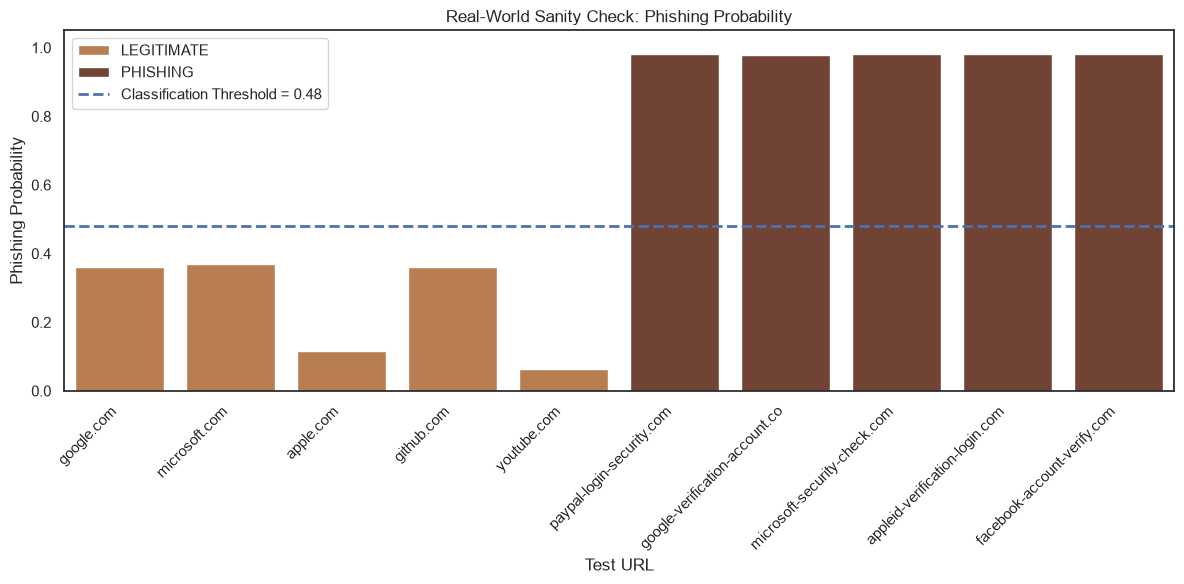

Figure saved: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\real_world_validation_probability.png


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

plot_df = validation_df.copy()
plot_df["Short_URL"] = plot_df["URL"].str.replace(
    r"https?://(www\.)?", "", regex=True
).str[:30]

sns.barplot(
    data=plot_df,
    x="Short_URL",
    y="Phishing_Probability",
    hue="Actual",
    palette=["#C97A40", "#7A3E2B"]
)

plt.axhline(
    loaded_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Classification Threshold = {loaded_threshold:.2f}"
)

plt.ylim(0, 1.05)
plt.ylabel("Phishing Probability")
plt.xlabel("Test URL")
plt.title("Real-World Sanity Check: Phishing Probability")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

output_path = FIGURE_DIR / "real_world_validation_probability.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved:", output_path)

In [34]:
# Load unseen validation dataset
unseen_path = PROJECT_ROOT / "data" / "validation" / "unseen_validation.csv"

unseen_df = pd.read_csv(unseen_path)

print("Unseen validation shape:", unseen_df.shape)
print("\nColumns:")
print(unseen_df.columns.tolist())

print("\nLabel distribution:")
print(unseen_df["Label"].value_counts())

Unseen validation shape: (100, 18)

Columns:
['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']

Label distribution:
Label
0    100
Name: count, dtype: int64


In [35]:
# Prepare unseen validation features
X_unseen = unseen_df[loaded_features].copy()
y_unseen = unseen_df["Label"].copy()

# Predict probabilities and classes
unseen_probabilities = loaded_model.predict_proba(X_unseen)[:, 1]
unseen_predictions = (
    unseen_probabilities >= loaded_threshold
).astype(int)

# Basic evaluation
false_positives = ((y_unseen == 0) & (unseen_predictions == 1)).sum()
correct_legitimate = ((y_unseen == 0) & (unseen_predictions == 0)).sum()

false_positive_rate = false_positives / len(y_unseen)
legitimate_detection_rate = correct_legitimate / len(y_unseen)

print("Unseen Validation Results")
print("-" * 50)
print(f"Total samples: {len(y_unseen)}")
print(f"Actual legitimate: {(y_unseen == 0).sum()}")
print(f"Predicted legitimate: {(unseen_predictions == 0).sum()}")
print(f"Predicted phishing: {(unseen_predictions == 1).sum()}")
print(f"False positives: {false_positives}")
print(f"False Positive Rate: {false_positive_rate:.4f}")
print(f"Legitimate Detection Rate: {legitimate_detection_rate:.4f}")
print(f"Mean phishing probability: {unseen_probabilities.mean():.4f}")

Unseen Validation Results
--------------------------------------------------
Total samples: 100
Actual legitimate: 100
Predicted legitimate: 97
Predicted phishing: 3
False positives: 3
False Positive Rate: 0.0300
Legitimate Detection Rate: 0.9700
Mean phishing probability: 0.2314


In [36]:
false_positive_mask = (
    (y_unseen == 0) &
    (unseen_predictions == 1)
)

false_positive_df = unseen_df.loc[
    false_positive_mask,
    ["Domain", "Label"]
].copy()

false_positive_df["Phishing_Probability"] = (
    unseen_probabilities[false_positive_mask]
)

false_positive_df = false_positive_df.sort_values(
    "Phishing_Probability",
    ascending=False
)

print("False Positive Cases:")
display(false_positive_df)

False Positive Cases:


,Domain,Label,Phishing_Probability
66,cloudflare-dns.com,0,0.903519
40,cloud.microsoft,0,0.648834
64,workers.dev,0,0.648834


In [37]:
# Inspect all model features for the false-positive cases

fp_features = unseen_df.loc[
    false_positive_mask,
    ["Domain"] + loaded_features
].copy()

fp_features["Phishing_Probability"] = (
    unseen_probabilities[false_positive_mask]
)

print("False-positive feature patterns:")
display(fp_features)

False-positive feature patterns:


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Web_Forwards,Phishing_Probability
40,cloud.microsoft,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0.648834
64,workers.dev,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0.648834
66,cloudflare-dns.com,0,0,0,0,0,0,0,1,0,1,0,1,1,0,0,0.903519
